# Advanced Certification Programme in Agentic and Generative AI
## A Programme by IISc and TalentSprint
### Additional Notebook: **Building Agent using LangChain 🦜🔗**

(Ungraded)

## Learning Objectives

At the end of the experiment, you will be able to:

* understand the difference between a tool and an agent
* use Agents in LangChain
* add different tools to your agent such as *wikipedia tool, math calculator, google search, python executor,* etc
* define your own tool to add to an agent

# Getting Started with Agent

**From AI to AI Agents: Extending Intelligence with Tools and Real-World Interaction**

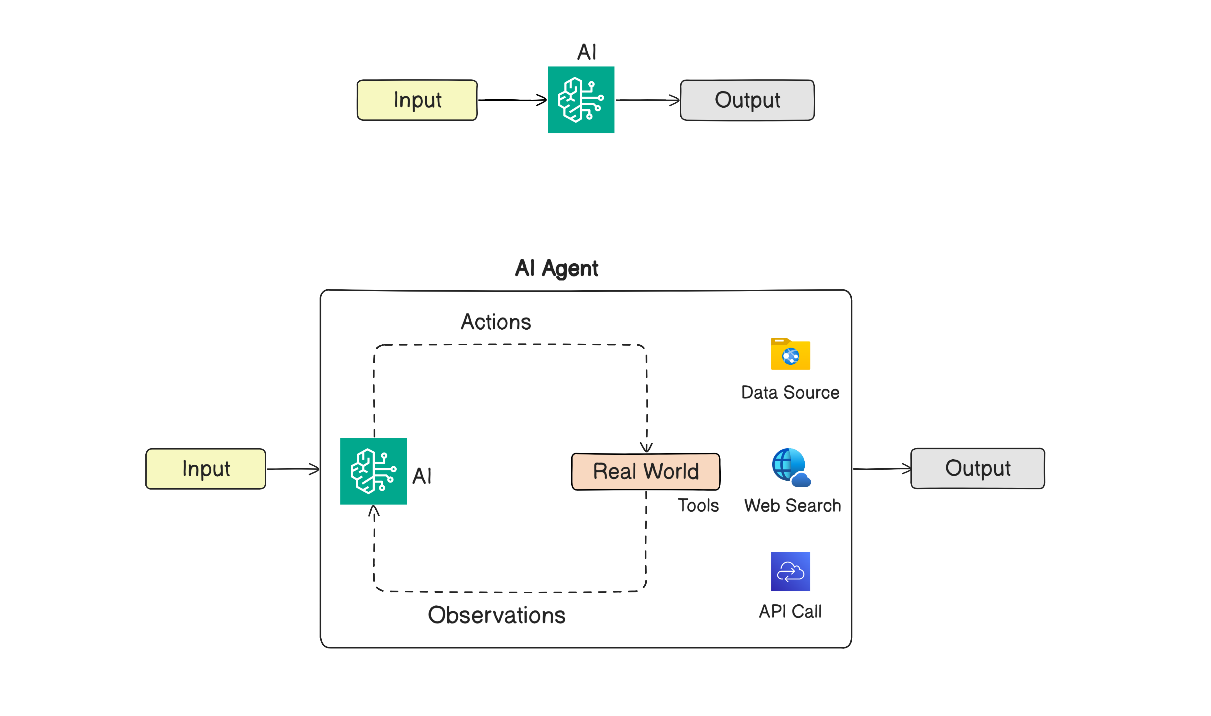

> **What are Tools?**
>
> Tools are helpful and act as a interface that an agent, a chain, or a chat model / LLM (Large Language Model) can use to ineract with the world. For e.g., Tools can be Search tool like SerpAPI, Google search etc.,. Given a list of tools and prompt, an LLM can request that one or more tools be invoked with appropriate arguments.

> **Whar are Agents?**
>
> In LangChain, an “**Agent**” is an AI entity that interacts with various “**Tools**” to perform tasks or answer queries. Tools are essentially functions that extend the agent's capabilities by allowing it to perform specific actions, like retrieving the current time or accessing an external database.

<img src='https://drive.google.com/uc?id=1Uo1YNVICwjpKm6PTZCdRGpuSKvTGL6q6' width=800px>

The basic code to create an agent in LangChain involves:
- defining tools,
- loading a template for ReAct prompting,
- initializing a language model, and
- creating an agent that uses ReAct prompting and language model.
- The agent is then executed using an **`AgentExecutor`**, which *manages the interaction between the agent and the tools*.

This setup allows for dynamic and context-aware responses, enabling the AI to reason and take actions in a structured manner.


### **ReAct Prompting**

Here, we will use an agent that will implement the [ReAct](https://react-lm.github.io/) logic.

**ReAct** overcomes issues of hallucination and error propagation prevalent in chain-of-thought reasoning by interacting with a simple Wikipedia API or any other APIs, and generates human-like task-solving trajectories that are more interpretable than baselines without reasoning traces.

<center><img src='https://react-lm.github.io/files/diagram.png' width=1000px></center>



A **ReAct prompt** consists of few-shot task-solving trajectories, with human-written text reasoning traces and actions, as well as environment observations in response to actions.

ReAct prompting is intuitive and flexible to design, and achieves state-of-the-art few-shot performances across a variety of tasks, from question answering to online shopping.
<br><br>

<img src='https://react-lm.github.io/files/hotpotqa.png' width=1200px>

**Sample ReAct prompt for Agents**

```
Answer the following questions as best you can. You have access to the following tools:

{tools}

Use the following format:

Question: the input question you must answer
Thought: you should always think about what to do
Action: the action to take, should be one of [{tool_names}]
Action Input: the input to the action
Observation: the result of the action
... (this Thought/Action/Action Input/Observation can repeat N times)
Thought: I now know the final answer
Final Answer: the final answer to the original input question

Begin!

Question: {input}
Thought:{agent_scratchpad}
```

The variables that must be passed as arguments to this prompt are as follows.

- **tools:** A description of the tool, including a description of the tool, input variables for each tool, and their description.
- **input:** question input by agent
- **tools_name:** Names of tools that the agent can use
- **agent_scratchpad:** The agent does not call a tool just once to get the desired answer, but has a structure that calls tools repeatedly until the desired answer is obtained. Each time you call a tool, what the previous call was like, information about the previous call, and the result are stored in this field. It is used to keep track of the agent's thoughts or actions during the execution of the program and let the agent continue its thought process.

The variable values in the prompt are filled in automatically, so there is no place to modify them. As for the prompt, you can also use the example that has already been written. If you just want to improve the agent’s performance, you can modify this prompt.


The prompt guides the agent’s operation mechanism.

```
Thought: you should always think about what to do
Action: the action to take, should be one of [{tool_names}]
Action Input: the input to the action
Observation: the result of the action
... (this Thought/Action/Action Input/Observation can repeat N times)
```

At the ***Thought*** stage, the agent uses llm to think about what action to take to get the answer to the question, and ***Action*** decides which tool to use, and ***Action Input*** creates a new question queried by the tool. And finally, ***Observation*** saves the results in the tool called by Action.

Through this sequence, the Agent executes [Thought --> Action --> Action Input --> Observation], saves the result in `agent_scratchpad`, and repeats this process until the desired answer is obtained.

Once you have created a prompt, create an agent using this prompt, and create and call an agent executor using this agent.

If an agent makes a decision about an incoming question and executes a tool, a subject is needed to repeatedly run the agent through this process until an answer is obtained. The agent executor plays this role.

### **Agent execution detailed structure**

The diagram below shows this execution structure graphically.

<img src='https://drive.google.com/uc?id=1c7PXH8bFLIsUawtNes99Ma6BQT24SYXR' width=700px>

When a <font color='#117799'>Question</font> comes in, insert this question into the <font color='#339955'>Agent Prompt</font> created earlier and deliver it to the agent.

To answer a question, the agent refers to the guide in the agent prompt and creates the necessary question (corresponds to <font color='#993333'>Question 1</font>: ***Action Input***) through the thought process. After receiving the answer (corresponding to <font color='#993333'>Answer 1</font>: ***Observation***) by calling the <font color='#339955'>Tool</font> (corresponding to ***Action***) that selected the question, append the answer to `agent_scratchpad` of the existing agent prompt.

The agent executor passes this agent prompt back to the agent, creates <font color='#993333'>Question 2</font> in the same order, receives the answer <font color='#993333'>Answer2</font>, and similarly appends it to the existing agent prompt.

When `agent_executor` passes this prompt to the agent again, if enough information necessary for the answer has been collected, the agent generates an answer based on the information in the prompt and returns the <font color='#117799'>Final Answer</font>.

### Install required dependencies

In [ ]:
%%capture
!pip -q install openai==2.3.0
!pip -q install langchain-core==0.3.79
!pip -q install langchain-community==0.3.31
!pip -q install sentence-transformers==5.1.1
!pip -q install langchain-huggingface==0.3.1
!pip -q install langchain-experimental==0.3.4
!pip -q install langchainhub==0.1.21
!pip -q install langchain-openai==0.3.35

# for wikipedia as a tool
!pip -q install -U wikipedia==1.4.0

# for google-search as a tool
!pip -q install google-search-results

### Import required packages

In [ ]:
import os
from google.colab import userdata

import openai
from langchain.prompts import PromptTemplate
from langchain import hub
from langchain.agents import load_tools, create_react_agent, AgentExecutor
from langchain.tools.render import render_text_description
from langchain_community.utilities import SerpAPIWrapper

### **Provide your Groq API key**

Using the Groq API Key, you will have access to the OpenAI and Llama model, free of cost, under the [Free-tier](https://console.groq.com/docs/rate-limits#rate-limits).

This cell retrieves the Groq API key securely stored in Google Colab's Secrets (see 'key' icon on the leftmost panel of this notebook) and sets it as an environment variable `GROQ_API_KEY`. This is a recommended practice to avoid exposing your API key directly in the code.


* Go to https://console.groq.com/, and setup a Free account.

* Create a new API by visiting: https://console.groq.com/keys

* Save the key in Google Colab's Secrets
    ```
    Secret Name: GROQ_API_KEY
    Secret Value: Paste your Groq api key
    ```

* Read the key and save as an environment variable `GROQ_API_KEY`

In [ ]:
# Save the key in Colab's Secrets then load from there

from google.colab import userdata

os.environ['GROQ_API_KEY'] = userdata.get('GROQ_API_KEY')

### **Load your Language Model**

In [ ]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(
    model="llama-3.3-70b-versatile",   # Groq-supported model
    temperature=0,
    api_key=os.getenv("GROQ_API_KEY"),
    base_url="https://api.groq.com/openai/v1"
)

# We are going to use this language model as the reasoning engine of the agent to connect to other data sources and perform computation
# so we want this reasoning engine to be as presice as possible.
# Hence, temperature is set to zero to get rid of any randomness.

In [ ]:
response = llm.invoke("What is 2 plus 3?")
print(response.content)

# **LangChain: Agents**

## Built-in LangChain [tools](https://docs.langchain.com/oss/python/integrations/tools)

Here, we will learn how to use

1. Wikipedia tool
2. LLM Math tool
3. Combine two or more tools
4. Google Search Engine tool
5. Python Agent
6. Define your own tool

### **1. Wikipedia tool**

`wikipedia` tool is an api that connects with wikipedia allowing to run search queries against wikipedia and get back the results.

**Load tools**

`load_tools`: Load tools based on their name.

Tools allow agents to interact with various resources and services like APIs, databases, file systems, etc.

To know more about `load_tools` API, refer [here](https://api.python.langchain.com/en/latest/agent_toolkits/langchain_community.agent_toolkits.load_tools.load_tools.html).

In [ ]:
from langchain.agents import load_tools

# Initialize tools
tools = load_tools(["wikipedia"])

tools

In [ ]:
type(tools)

In [ ]:
from langchain.tools.render import render_text_description

# Render tools description
render_text_description(tools)

**Pull ReAct Prompt**

In [ ]:
# Pull the ReAct style prompt template from the hub ; ReAct = Reason and Action
# https://smith.langchain.com/hub/hwchase17/react

from langchain import hub

prompt = hub.pull("hwchase17/react")

In [ ]:
print(prompt.template)

#### **Create ReAct Agent**

`create_react_agent()` creates a ReAct agent using the specified model (llm), tools (tools), and prompt template (prompt).

In [ ]:
# Create the ReAct agent using the create_react_agent function

from langchain.agents import create_react_agent

agent = create_react_agent(
    llm=llm,                         # LLM to use as the agent
    tools=tools,                     # Tools this agent has access to
    prompt=prompt,                   # The prompt to use
    stop_sequence=True,              # stop_sequence=True ensures that the agent stops processing when it reaches a predefined
                                     # stopping point in the conversation. If True, adds a stop token of “Observation:” to avoid hallucinates.
)

In [ ]:
# Create an agent executor from the agent and tools

from langchain.agents import AgentExecutor

agent_executor = AgentExecutor.from_agent_and_tools(
    agent=agent,         # Agent to use
    tools=tools,         # Tools to use
    verbose=True,
)

In [ ]:
# Run the agent with a test query

response = agent_executor.invoke(
    {
        "input": "Which of them was built first - Eiffel Tower or Taj Mahal?"
    }
)
response

In [ ]:
response

### **2. LLM Math tool**

`llm-math` tool is a chain itself which uses a language model in conjuction with a calculater to do math problems.

In [ ]:
tools = load_tools(["llm-math"], llm=llm)

tools

In [ ]:
render_text_description(tools)

In [ ]:
# Create the ReAct agent using the create_react_agent function

agent = create_react_agent(
    llm=llm,
    tools=tools,
    prompt=prompt,
    stop_sequence=True,
)

In [ ]:
# Create an agent executor from the agent and tools

agent_executor = AgentExecutor.from_agent_and_tools(
    agent=agent,
    tools=tools,
    verbose=True,
)

In [ ]:
# Run the agent with a test query

response = agent_executor.invoke(
    {
        "input": "What is 10% of 500?"
    }
)
response

In [ ]:
# Run the agent with a test query

response = agent_executor.invoke(
    {
        "input": "What is 20% of 500?"
    }
)
response

### **3. Combining two or more tools**

In [ ]:
tools = load_tools(["llm-math", "wikipedia"], llm=llm)
print(render_text_description(tools))

In [ ]:
# Create the ReAct agent using the create_react_agent function

agent = create_react_agent(
    llm=llm,
    tools=tools,
    prompt=prompt,
    stop_sequence=True,
)

In [ ]:
# Create an agent executor from the agent and tools

agent_executor = AgentExecutor.from_agent_and_tools(
    agent=agent,
    tools=tools,
    verbose=True,
)

In [ ]:
question1 = "What is the height of Eiffel Tower?"

result = agent_executor.invoke({"input": question1})
result

In [ ]:
question2 = "What is 20% of 500?"

result = agent_executor.invoke({"input": question2})
result

In [ ]:
question3 = "What is the height of Eiffel Tower? Divide the result by 2 "

result = agent_executor.invoke({"input": question3})
result

### **4. Google Search Engine**

Certain tools require API Keys. In this example, we use SERPER API.

Create a new account and access your API KEY HERE:
https://serpapi.com/users/welcome

**Provide your SerpAPI key**

In [ ]:
# Add your SerpAPI key to Colab Secrets with name 'SERPAPI_KEY' then run this cell

serp_api_key = userdata.get('SERPAPI_KEY')
os.environ["SERPAPI_API_KEY"] = serp_api_key

del serp_api_key

In [ ]:
# Setup tools

tools = load_tools(["serpapi", "llm-math"], llm=llm)
print(render_text_description(tools))

In [ ]:
# Create the ReAct agent using the create_react_agent function

agent = create_react_agent(
    llm=llm,
    tools=tools,
    prompt=prompt,
    stop_sequence=True,
)

In [ ]:
# Create an agent executor from the agent and tools

agent_executor = AgentExecutor.from_agent_and_tools(
    agent=agent,
    tools=tools,
    verbose=True,
)

In [ ]:
result = agent_executor.invoke(
    {
        "input": "Which of them was built first - Eiffel Tower or Taj Mahal?"
    }
)
result

In [ ]:
result = agent_executor.invoke(
    {
        "input": "What is the height of Eiffel Tower in meters? Divide the resultant by 2?"
    }
)
result

### **5. Python Agent**

Sometimes, for complex calculations, rather than have an LLM generate the answer directly, it can be better to have the LLM generate code to calculate the answer, and then run that code to get the answer.

The **Python REPL** is a powerful tool for interactive programming, making it easy to experiment with Python code and get immediate feedback.

It allows you to enter Python code, evaluate it immediately, and see the results right away.

Components of Python REPL:

* **Read:** The REPL reads the input you provide. This can be a single line of code, a block of code, or even multiple commands in succession.

* **Eval:** The input is evaluated (executed) by the Python interpreter. This means that the code you entered is processed, and any calculations or operations are performed.

* **Print:** The results of the evaluation are printed to the screen. This allows you to see the output immediately after entering your code.

* **Loop:** After printing the result, the REPL loops back to read the next input, allowing you to continue interacting with the interpreter.

In [ ]:
from langchain_experimental.agents.agent_toolkits import create_python_agent
from langchain_experimental.utilities import PythonREPL

In [ ]:
python_repl = PythonREPL()

In [ ]:
python_repl.run("print(1+1)")

In [ ]:
python_repl.run("print('Hello world')")

In [ ]:
# Create the tool to pass to an agent

from langchain_core.tools import Tool

repl_tool = Tool(
    name="python_repl",
    description="A Python shell. Use this to execute python commands. Input should be a valid python command. If you want to see the output of a value, you should print it out with `print(...)`.",
    func=python_repl.run,
)

In [ ]:
# Setup tools

tools = load_tools([], llm=llm) + [repl_tool, ]

tools[0].name

In [ ]:
# Create the ReAct agent using the create_react_agent function

agent = create_react_agent(
    llm=llm,
    tools=tools,
    prompt=prompt,
    stop_sequence=True,
)

In [ ]:
# Create an agent executor from the agent and tools

agent_executor = AgentExecutor.from_agent_and_tools(
    agent=agent,
    tools=tools,
    verbose=True,
)

In [ ]:
# Example 1

result = agent_executor.invoke(
    {
        "input": "Sort the following list ['Daisy', 'Elsa', 'Alan', 'Ben', 'Claire'] and print the result"
    }
)
result

In [ ]:
# Example 2

result = agent_executor.invoke(
    {
        "input": "print(len('hello') + 5)"
    }
)
result

### **6. Define your own tool**

Try getting the current time from the Agent:

In [ ]:
tools = load_tools([], llm=llm)

# Create the ReAct agent using the create_react_agent function
agent = create_react_agent(
    llm=llm,
    tools=tools,
    prompt=prompt,
    stop_sequence=True,
)

# Create an agent executor from the agent and tools
agent_executor = AgentExecutor.from_agent_and_tools(
    agent=agent,
    tools=tools,
    verbose=True,
)

In [ ]:
result = agent_executor.invoke(
    {
        "input": "What is the current time?"
    }
)
result

Create our own function to get current time:

In [ ]:
import datetime as dt

def timefunc(text: str) -> str:
    dt_india = dt.datetime.now(dt.UTC) + dt.timedelta(hours=5, minutes=30)
    return dt_india.strftime('%Y-%m-%d %H:%M:%S.%f')

In [ ]:
timefunc('')

In [ ]:
# Create the tool to pass to an agent

# First, we have to import the tool decorator which convert any function as tool that langchain can use.
from langchain_core.tools import Tool

timetool = Tool(
    name="time_tool",
    description="""Returns current date and time, use this for any \
    questions related to knowing current date and Indian time. \
    The input should always be an empty string, \
    and this function will always return current  \
    date and time.""",
    func = timefunc,
)

In [ ]:
tools = load_tools([], llm=llm) + [timetool, ]
tools

In [ ]:
# Create the ReAct agent using the create_react_agent function

agent = create_react_agent(
    llm=llm,
    tools=tools,
    prompt=prompt,
    stop_sequence=True,
)

In [ ]:
# Create an agent executor from the agent and tools

agent_executor = AgentExecutor.from_agent_and_tools(
    agent=agent,
    tools=tools,
    verbose=True,
)

In [ ]:
result = agent_executor.invoke({"input": "What is the current time?"})
result

### **Tool to make a Weather API call**

**OpenWeather** is a weather data provider that uses AI and machine learning to offer historical, current, and forecasted weather data for any location worldwide via light-speed APIs.

Open Weather Map is [integrated](https://docs.langchain.com/oss/python/integrations/tools/openweathermap) into LangChain.

We need to
- install `pyown`,
- create an API key on the website of [OpenWeatherMap](https://openweathermap.org/api/) (which might take a few hours to activate), and
- then run the cells below to get weather of a given city.

Note that the first 1,000 API calls per day are FREE.

In [ ]:
!pip -q install pyowm

In [ ]:
from langchain_community.utilities import OpenWeatherMapAPIWrapper

os.environ["OPENWEATHERMAP_API_KEY"] = userdata.get("OPENWEATHERMAP_API_KEY")

weather = OpenWeatherMapAPIWrapper()

In [ ]:
weather_data = weather.run("Las Vegas")
print(weather_data)

In [ ]:
weather_data = weather.run("Hyderabad")
print(weather_data)

In [ ]:
# Create the tool to pass to an agent

from langchain_core.tools import Tool

weather_tool = Tool(
    name="weather_tool",
    description="""Get the weather details for the given city.\
    The input should always be a string representing the city name, \
    and this function will always return a json format response with weather details. """,
    func = weather.run,
)

In [ ]:
tools = load_tools(["serpapi"], llm=llm) + [weather_tool]
tools

In [ ]:
# Create the ReAct agent using the create_react_agent function

agent = create_react_agent(
    llm=llm,
    tools=tools,
    prompt=prompt,
    stop_sequence=True,
)

In [ ]:
# Create an agent executor from the agent and tools

agent_executor = AgentExecutor.from_agent_and_tools(
    agent=agent,
    tools=tools,
    verbose=True,
)

In [ ]:
result = agent_executor.invoke(
    {
        "input": "How is the weather in Hyderabad?"
    }
)
result

In [ ]:
result = agent_executor.invoke(
    {
        "input": "Who is the Mayor of New York City in 2026?"
    }
)
result

In [ ]:
result = agent_executor.invoke(
    {
        "input": "Zohran Mamdani is the Mayor of which city, and how is the weather there?"
    }
)
result

---

<center>
$END$
</center>

---